**brief description :** The car crash dataset provides a detailed compilation of information related to common factors influencing road accidents, offering valuable insights for the analysis and enhancement of overall road safety measures.

In [133]:
import pandas as pd

In [134]:
df = pd.read_excel('monroe county car crach 2003-2015.xlsx')
df = pd.DataFrame(df)
df.head()

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
0,2015,1,5,Weekday,0.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,1ST & FESS,39.159207,-86.525874
1,2015,1,6,Weekday,1500.0,2-Car,No injury/unknown,FOLLOWING TOO CLOSELY,2ND & COLLEGE,39.161440,-86.534848
2,2015,1,6,Weekend,2300.0,2-Car,Non-incapacitating,DISREGARD SIGNAL/REG SIGN,BASSWOOD & BLOOMFIELD,39.149780,-86.568890
3,2015,1,7,Weekend,900.0,2-Car,Non-incapacitating,FAILURE TO YIELD RIGHT OF WAY,GATES & JACOBS,39.165655,-86.575956
4,2015,1,7,Weekend,1100.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,W 3RD,39.164848,-86.579625


In [135]:
print (f'the dataframe shape   {df.shape}')

the dataframe shape   (53943, 11)


In [136]:
df = df.sample(n=800)

In [137]:
print (f'the dataframe shape after taking a sample out of it   {df.shape}')

the dataframe shape after taking a sample out of it   (800, 11)


# Data Processing

In [138]:
import numpy as np

# Replace 0 in Latitude and Longitude columns with NaN
df['Latitude'] = df['Latitude'].replace(0, np.nan )
df['Longitude'] = df['Longitude'].replace(0, np.nan )


In [139]:
print(df.isnull().sum()) # Calculate the missing value in each column

Year                  0
Month                 0
Day                   0
Weekend?              2
Hour                  2
Collision Type        0
Injury Type           0
Primary Factor       17
Reported_Location     1
Latitude             72
Longitude            72
dtype: int64


In [140]:
df = df.dropna() #To remove missing value
df

,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude
49864,2003,8,1,Weekend,100.0,1-Car,No injury/unknown,LEFT OF CENTER,DUNN ST & SR45,39.186352,-86.528496
22936,2010,12,6,Weekday,1200.0,2-Car,No injury/unknown,UNSAFE BACKING,E 3RD ST ST,39.164240,-86.494260
38130,2006,12,1,Weekend,1800.0,2-Car,No injury/unknown,OTHER (VEHICLE) - EXPLAIN IN NARRATIVE,W WHITEHALL CROSSING BLVD,39.171921,-86.572640
35936,2007,2,3,Weekday,1400.0,2-Car,Non-incapacitating,LEFT OF CENTER,BLOOMFIELD & OAKDALE DR,39.148046,-86.571515
1912,2015,6,7,Weekend,1700.0,2-Car,No injury/unknown,UNSAFE LANE MOVEMENT,3RD & HIGHLAND,39.164275,-86.517727
...,...,...,...,...,...,...,...,...,...,...,...
7286,2014,3,4,Weekday,1000.0,2-Car,Non-incapacitating,FOLLOWING TOO CLOSELY,CONSTITUTION & LIBERTY DR,39.149552,-86.575936
9572,2013,12,1,Weekend,1800.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,11TH ST & ADAMS,39.173240,-86.549810
48684,2004,12,1,Weekend,200.0,2-Car,No injury/unknown,OTHER (DRIVER) - EXPLAIN IN NARRATIVE,CORY LANE & W 2ND,39.109829,-86.560095
44405,2005,10,2,Weekday,1400.0,2-Car,No injury/unknown,FAILURE TO YIELD RIGHT OF WAY,S WALNUT ST & WALNUT ST,39.107344,-86.526400


In [141]:
df['Month'].unique()

array([ 8, 12,  2,  6,  1, 11,  9, 10,  7,  4,  5,  3])

In [142]:
# Categorise Data
# map the months to their corresponding seasons using a doctionary
# this help us group the data by seasons instead of months
mapping = {12:'winter', 1:'winter', 2:'winter',3:'spring',4:'spring',5:'spring',6:'summer',7:'summer',8:'summer',9:'fall',10:'fall',11:'fall' }
df['Seasons']=df['Month'].map(mapping)
df['Seasons']

,Seasons
49864,summer
22936,winter
38130,winter
35936,winter
1912,summer
...,...
7286,spring
9572,winter
48684,winter
44405,fall


In [143]:
df['Hour'].unique()

array([ 100., 1200., 1800., 1400., 1700., 1600.,  400., 1900.,  500.,
        900.,  200., 2300., 1100.,  700., 2200., 1300., 2000., 1500.,
       2100., 1000.,  800.,    0.,  600.,  300.])

In [144]:
# Categorise Data
# map the hours to their corresponding period using a doctionary
# this help us group the data by period instead of hours
mapping = {600:'morning',700:'morning',800:'morning',900:'morning',1000:'morning',1100:'morning',
           1200:'afternoon',1300:'afternoon',1400:'afternoon',1500:'afternoon',1600:'afternoon',1700:'afternoon',
           1800:'evening',1900:'evening',2000:'evening',2100:'evening',2200:'evening',2300:'evening',
           0:'late night',100:'late night',200:'late night',300:'late night',400:'late night',500:'late night'}
df['period']=df['Hour'].map(mapping)
df['period']

,period
49864,late night
22936,afternoon
38130,evening
35936,afternoon
1912,afternoon
...,...
7286,morning
9572,evening
48684,late night
44405,afternoon


In [145]:
#remove punctuation marks
# refrence(regex=True):https://stackoverflow.com/questions/66603854/futurewarning-the-default-value-of-regex-will-change-from-true-to-false-in-a-fu
df['Primary Factor'] = df['Primary Factor'].str.replace(r'[\"\&\'\(\)\*\+\,\-\.\:\;\<\=\/\>\?\@\[\_\`\{\|\}\~]',' ',regex=True) #Replace the symbols inside the brackets with a space.
df['Primary Factor']

,Primary Factor
49864,LEFT OF CENTER
22936,UNSAFE BACKING
38130,OTHER VEHICLE EXPLAIN IN NARRATIVE
35936,LEFT OF CENTER
1912,UNSAFE LANE MOVEMENT
...,...
7286,FOLLOWING TOO CLOSELY
9572,OTHER DRIVER EXPLAIN IN NARRATIVE
48684,OTHER DRIVER EXPLAIN IN NARRATIVE
44405,FAILURE TO YIELD RIGHT OF WAY


In [146]:
# download stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))
print(stop_words)

{"hasn't", 'on', 'who', 'between', "don't", 'are', 'why', 'not', 'will', "haven't", 'mustn', 'only', 'few', 'what', 't', "hadn't", "you'll", 'too', "won't", "doesn't", 'does', 'above', 'from', 'just', 'don', 'do', 'own', 'other', "wasn't", 'once', 'same', 'y', 'those', "mightn't", 'of', 'have', 'off', 'until', 'their', 'themselves', 'didn', 'about', 'because', 've', 'doesn', 'some', "couldn't", 'below', 'through', 'where', 'more', 'is', 'if', 'to', 'll', 'o', 'ourselves', 'the', 'by', 'down', 'now', "you've", 'd', 'shouldn', 'such', "weren't", 'again', 'wasn', 'your', 'i', 'has', 'needn', 'after', 'and', 'than', 'm', "shan't", 'during', 'him', "shouldn't", 'out', 'that', 'against', 'at', 'been', 'while', 'hasn', 'am', 'it', 'himself', 'theirs', 'how', 'both', 'before', 'a', 'herself', "mustn't", "you'd", 'won', 'having', 'were', 'shan', 'did', 'then', 's', 'her', 'in', 'our', 'she', 'my', 'over', 'as', 'me', 'up', "aren't", 'had', 'aren', "that'll", 'most', 'these', 'yourselves', 'ther

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [147]:
#remove stop words
#It helps us to delete unimportant words.
df ['Primary Factor'] = df ['Primary Factor'].map(lambda x:' '.join([word for word in x.split() if word.lower() not in stop_words])) # Mapping takes function using lambda and join is used to return text to string
df['Primary Factor']

,Primary Factor
49864,LEFT CENTER
22936,UNSAFE BACKING
38130,VEHICLE EXPLAIN NARRATIVE
35936,LEFT CENTER
1912,UNSAFE LANE MOVEMENT
...,...
7286,FOLLOWING CLOSELY
9572,DRIVER EXPLAIN NARRATIVE
48684,DRIVER EXPLAIN NARRATIVE
44405,FAILURE YIELD RIGHT WAY


In [148]:
#download
#refrance punkt_tab : https://stackoverflow.com/questions/78862426/unable-to-use-nltk-functions
#It helps us divide the text into sentences to make them easier to count.
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt_tab')
def token (text):
       text = nltk.sent_tokenize(text)
       return text


df['Primary Factor'] = df['Primary Factor'].map(token) # take arg(function) and applies to all values
df['Primary Factor']

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Primary Factor
49864,[LEFT CENTER]
22936,[UNSAFE BACKING]
38130,[VEHICLE EXPLAIN NARRATIVE]
35936,[LEFT CENTER]
1912,[UNSAFE LANE MOVEMENT]
...,...
7286,[FOLLOWING CLOSELY]
9572,[DRIVER EXPLAIN NARRATIVE]
48684,[DRIVER EXPLAIN NARRATIVE]
44405,[FAILURE YIELD RIGHT WAY]


In [149]:
# Validate Latitude and Longitude (geographic coordinate system)
# filter out the raws of Latitude and Longitude that doesn't meet the valid requirements
valid_coordinate = (df['Latitude'].between(-90, 90)) & (df['Longitude'].between(-180, 180))
df = df[valid_coordinate]

In [150]:
print (f'the dataframe shape after all the data cleaning and preprocessing {df.shape}')

the dataframe shape after all the data cleaning and preprocessing (712, 13)


# Data Analysis

In [151]:
# This creates a table to show how many times each time period happens in each season
period_Seasons_crosstab = pd.crosstab(df['Seasons'], df['period'])
period_Seasons_crosstab

period,afternoon,evening,late night,morning
Seasons,,,,
fall,84,56,17,43
spring,77,33,14,40
summer,70,30,7,41
winter,96,36,18,50


In [152]:
# Create a method to map each number with the corresponding day
def map_day(day):
  match day:
    case 1:
      return 'Monday'
    case 2:
      return 'Tuesday'
    case 3:
      return 'Wednesday'
    case 4:
      return 'Thursday'
    case 5:
      return 'Friday'
    case 6:
      return 'Saturday'
    case 7:
      return 'Sunday'

df['Days'] = df['Day'].apply(map_day)
#Passing function(map_day) and apply it to all element in the day column, and stored in the new column(Days)
df['Days']

,Days
49864,Monday
22936,Saturday
38130,Monday
35936,Wednesday
1912,Sunday
...,...
7286,Thursday
9572,Monday
48684,Monday
44405,Tuesday


In [153]:
import statistics as st

print('The mode of Day column :')
print(df['Days'].mode()) #To find the most frequent day of the Day column

The mode of Day column :
0    Saturday
Name: Days, dtype: object


In [154]:
#Counting the frequency of sentences
#Helps us identify the most common cause of accidents.
tokens = df['Primary Factor'].astype(str)    #Convert it to a string to be passed to the Counter function.
from collections import Counter
counter = Counter(tokens)
print(counter)                              # display as a dictionary

Counter({"['FAILURE YIELD RIGHT WAY']": 136, "['FOLLOWING CLOSELY']": 116, "['DRIVER EXPLAIN NARRATIVE']": 69, "['UNSAFE BACKING']": 66, "['DISREGARD SIGNAL REG SIGN']": 44, "['RAN ROAD RIGHT']": 34, "['DRIVER DISTRACTED EXPLAIN NARRATIVE']": 33, "['IMPROPER TURNING']": 28, "['SPEED FAST WEATHER CONDITIONS']": 26, "['UNSAFE SPEED']": 26, "['ANIMAL OBJECT ROADWAY']": 15, "['LEFT CENTER']": 14, "['UNSAFE LANE MOVEMENT']": 14, "['IMPROPER LANE USAGE']": 13, "['ROADWAY SURFACE CONDITION']": 11, "['VEHICLE EXPLAIN NARRATIVE']": 10, "['OVERCORRECTING OVERSTEERING']": 10, "['ALCOHOLIC BEVERAGES']": 8, "['PEDESTRIAN ACTION']": 7, "['DRIVER ASLEEP FATIGUED']": 6, "['IMPROPER PASSING']": 5, "['ENVIRONMENTAL EXPLAIN NARR']": 4, "['CELL PHONE USAGE']": 3, "['BRAKE FAILURE DEFECTIVE']": 2, "['PRESCRIPTION DRUGS']": 2, "['VIEW OBSTRUCTED']": 1, "['TIRE FAILURE DEFECTIVE']": 1, "['TELEMATICS USE']": 1, "['DRIVER ILLNESS']": 1, "['OBSTRUCTION MARKED']": 1, "['GLARE']": 1, "['LIGHTS DEFECTIVE']": 1, "[

In [155]:
# grouping data
# number of Car accidents Analysis (number of car crash  per year)
number_of_car_crash = df.groupby('Year').size()
print('number of of car crashes over each year ')
number_of_car_crash

number of of car crashes over each year 


,0
Year,
2003,33
2004,57
2005,46
2006,64
2007,57
2008,55
2009,52
2010,57
2011,56


In [156]:
# i use groupby to collict or groubing the data in colum of Collision Type
# size is importent if i use groupby it is the one who does count number of rows in the groub Collision Type
# i use reset_index(name = 'count') to add new colum named count and this way i have new DataFrame with tow colums 1- collision Type 2- count
theType = df.groupby('Collision Type').size().reset_index(name = 'count')
print(theType)

     Collision Type  count
0             1-Car    115
1             2-Car    518
2           3+ Cars     42
3               Bus      3
4           Cyclist      8
5  Moped/Motorcycle     12
6        Pedestrian     14


In [157]:
# i use this line to make date by specifying determining Year , Mounth,and new colum start with day1 to set the day
df['Date'] = pd.to_datetime(df[['Year','Month']].assign(Day=1))
# this line for performs data aggregation by colum Date
dayInMounth = df.groupby('Date').size()
dayInMounth

,0
Date,
2003-01-01,2
2003-02-01,5
2003-03-01,1
2003-04-01,1
2003-05-01,2
...,...
2015-08-01,6
2015-09-01,8
2015-10-01,6


In [158]:
print (f'the dataframe shape after all the data Analysis  {df.shape}')
df

the dataframe shape after all the data Analysis  (712, 15)


,Year,Month,Day,Weekend?,Hour,Collision Type,Injury Type,Primary Factor,Reported_Location,Latitude,Longitude,Seasons,period,Days,Date
49864,2003,8,1,Weekend,100.0,1-Car,No injury/unknown,[LEFT CENTER],DUNN ST & SR45,39.186352,-86.528496,summer,late night,Monday,2003-08-01
22936,2010,12,6,Weekday,1200.0,2-Car,No injury/unknown,[UNSAFE BACKING],E 3RD ST ST,39.164240,-86.494260,winter,afternoon,Saturday,2010-12-01
38130,2006,12,1,Weekend,1800.0,2-Car,No injury/unknown,[VEHICLE EXPLAIN NARRATIVE],W WHITEHALL CROSSING BLVD,39.171921,-86.572640,winter,evening,Monday,2006-12-01
35936,2007,2,3,Weekday,1400.0,2-Car,Non-incapacitating,[LEFT CENTER],BLOOMFIELD & OAKDALE DR,39.148046,-86.571515,winter,afternoon,Wednesday,2007-02-01
1912,2015,6,7,Weekend,1700.0,2-Car,No injury/unknown,[UNSAFE LANE MOVEMENT],3RD & HIGHLAND,39.164275,-86.517727,summer,afternoon,Sunday,2015-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7286,2014,3,4,Weekday,1000.0,2-Car,Non-incapacitating,[FOLLOWING CLOSELY],CONSTITUTION & LIBERTY DR,39.149552,-86.575936,spring,morning,Thursday,2014-03-01
9572,2013,12,1,Weekend,1800.0,2-Car,No injury/unknown,[DRIVER EXPLAIN NARRATIVE],11TH ST & ADAMS,39.173240,-86.549810,winter,evening,Monday,2013-12-01
48684,2004,12,1,Weekend,200.0,2-Car,No injury/unknown,[DRIVER EXPLAIN NARRATIVE],CORY LANE & W 2ND,39.109829,-86.560095,winter,late night,Monday,2004-12-01
44405,2005,10,2,Weekday,1400.0,2-Car,No injury/unknown,[FAILURE YIELD RIGHT WAY],S WALNUT ST & WALNUT ST,39.107344,-86.526400,fall,afternoon,Tuesday,2005-10-01


# Data Visualization

Text(70.72222222222221, 0.5, 'Seasons')

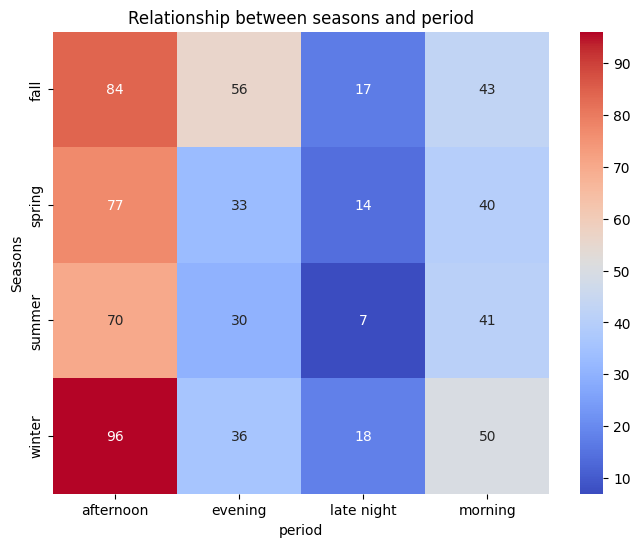

In [159]:
# creates a heatmap to visualize the relationship between variables
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(period_Seasons_crosstab, annot=True,fmt='d', cmap='coolwarm')
# annot=true: displays the freqency values, fmt=d: Displays the freqency as integers, cmap: sets the color palette
plt.title('Relationship between seasons and period')
plt.xlabel('period')
plt.ylabel('Seasons')

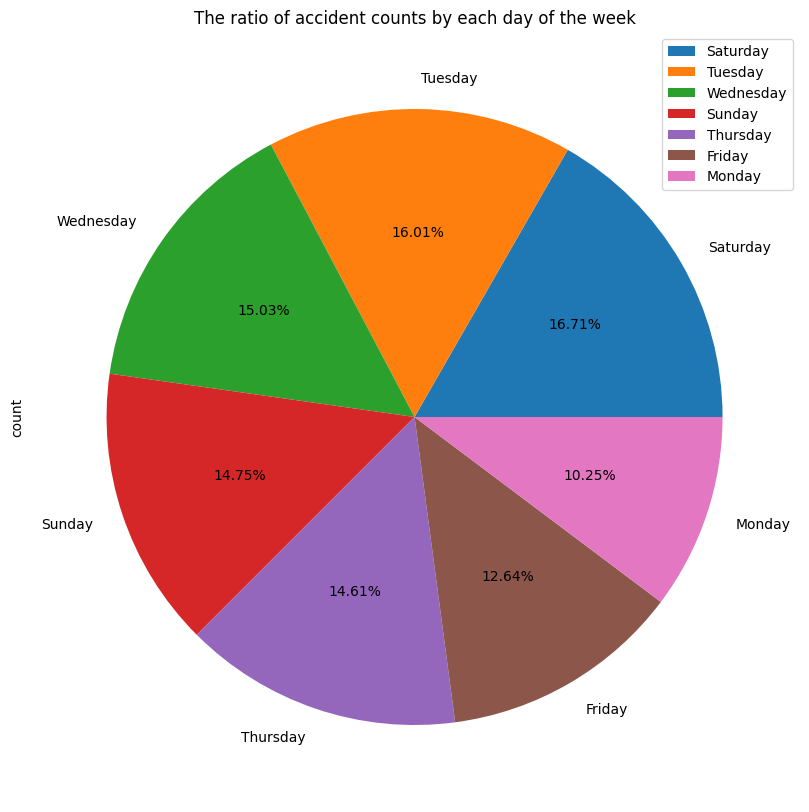

In [160]:
#Create a pie chart to represent the days
import matplotlib.pyplot as plt

day_counts = df['Days'].value_counts() #To find the count of each day an accident occurred

day_counts.plot(kind='pie', title='The ratio of accident counts by each day of the week', figsize=(10,10), autopct='%1.2f%%')
#autopct function return a string, used to label the wedges with their numeric value
plt.legend() #To show me what each color represents(day)
plt.show() #display the piechart

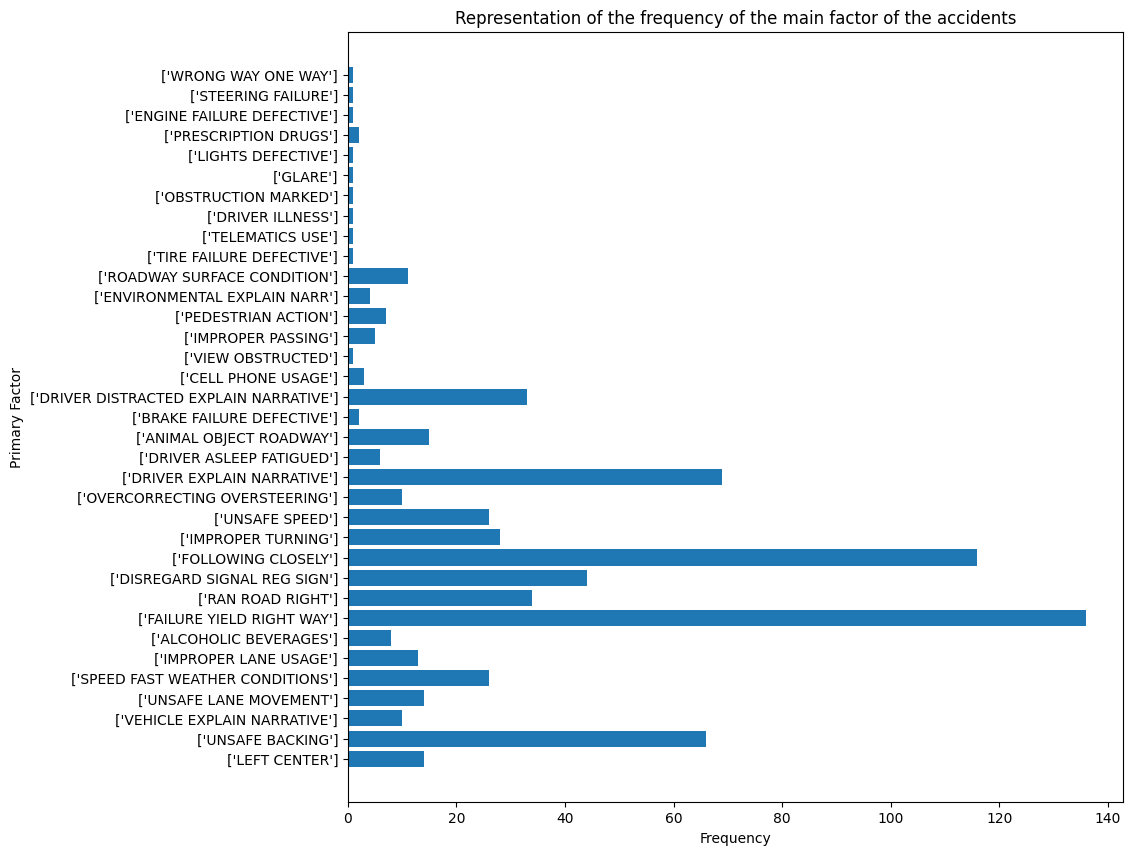

In [161]:
import matplotlib.pyplot as plt
#refrence: https://www.youtube.com/watch?v=9VK8quGFcSE
word = list(counter.keys())     #Convert it to List to fit the bar chart function.
count = list (counter.values()) #Convert it to List to fit the bar chart function.
plt.figure(figsize=(10, 10))    # Shape size
plt.barh(word, count)           #Bar chart representation as horizantel
plt.title("Representation of the frequency of the main factor of the accidents")
plt.ylabel("Primary Factor")
plt.xlabel("Frequency")
plt.show()

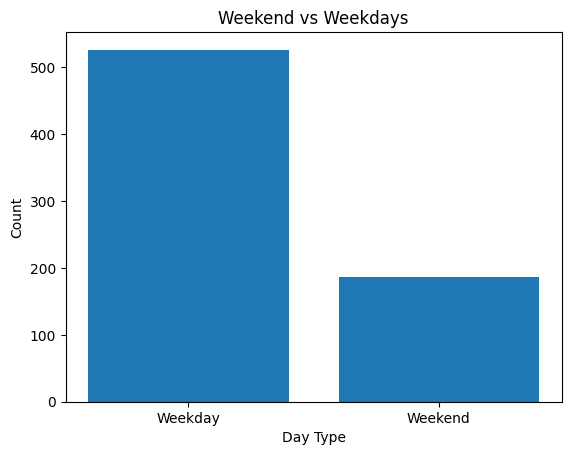

In [162]:
# Bar Chart for Weekend vs Weekday
weekday_counts = df['Weekend?'].value_counts()
plt.bar(weekday_counts.index , weekday_counts.values )
plt.title ('Weekend vs Weekdays')
plt.xlabel('Day Type')
plt.ylabel('Count')
plt.show()


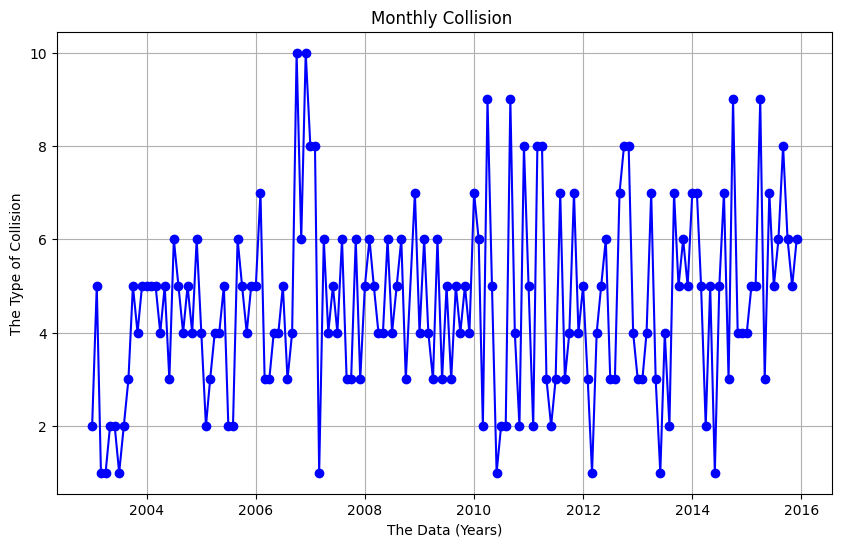

In [163]:

# create a new figure (10 inch width ,6 inch tall)
plt.figure(figsize=(10,6))
# i represent data in X axis and Y axis
# marker it is builds point '0' shape
# linestyle  conect between the markers
# color='b' it is blue color
plt.plot(dayInMounth.index,dayInMounth.values,marker='o',linestyle='-',color='b')
#Title name
plt.title('Monthly Collision ')
# X axis name
plt.xlabel('The Data (Years)')
# y axis name
plt.ylabel('The Type of Collision')
# with grid i choose whether there will be a grid or not
plt.grid(True)
# show will be show it
plt.show()

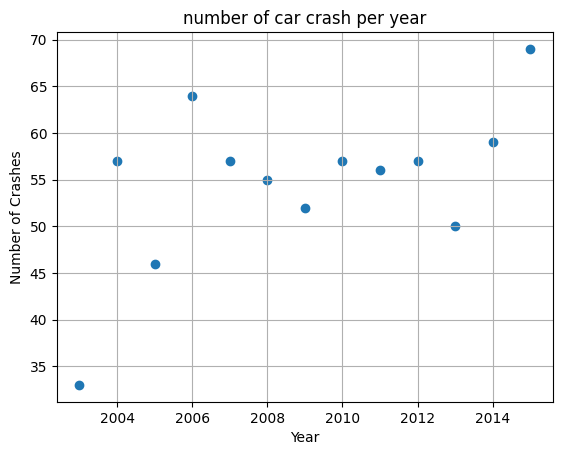

In [164]:
# scatter plot for number of car crash per year
plt.scatter(number_of_car_crash.index, number_of_car_crash.values)
plt.title('number of car crash per year')
plt.xlabel('Year')
plt.ylabel('Number of Crashes')
plt.grid(True)
plt.show()


# contribution report
***Team members and Contributions:***



**1- Razan Hamdan Almuzaini**

- Data processing - Categorise data
- Data Analysis - Crosstab
- Data visualization - Heatmap

Resources used:

- Wes McKinney - Python for Data Analysis_ Data Wrangling with pandas, NumPy, and Jupyter-OReilly Media (2022), page 229, 322

- https://www.datacamp.com/tutorial/seaborn-heatmaps

**2- Saja Abdulbaqi Alsaedi**
- Data processing - Remove missing value
- Data Analysis - Mode ( Day ), Mapping each number with the corresponding day
- Data visualization - Pie chart

Resources used :
- https://www.datacamp.com/tutorial/python-switch-case ( In mapping each number with the corresponding day )
- https://pandas.pydata.org/docs/index.html
( In dropna - isnull function)
- https://www.geeksforgeeks.org/python-pandas-index-value_counts/ ( In value_count function )
- https://www.codecademy.com/resources/docs/matplotlib/pyplot/pie ( In create pie chart )

**3- Rahaf Majed Alharbi**

*   Data processing - Remove stopwords and Tokenizing text data (Primary Factor)
*   Data Analysis - Finding the most frequent primary factor
*   Data visualization - Bar chart


Resources used:

1. (import nltk): https://stackoverflow.com/questions/38274356removing-stopwords-using-nltk-in-python/38274715#38274715
2. (visualization : Use dictionary to represent it in bar. ):https://www.youtube.com/watch?v=mvdNajTf6d8




Report:I removed punctuation marks and common words to simplify the text, then divided it into sentences using the NLTK library. I calculated repeated sentences to identify the most common cause of accidents and represented the results in a bar chart. The analysis showed that the most common cause is "failure to yield the right of way."



**4- Rose khaled Alamri**

Data processing :

- Replacing inappropriate values with NaN

- validating data (validating data of Latitude and Longitude columns)

Data Analysis :

- counting number of car accidents per year

Data visualization :

- Bar char for column (weekend?)

- scatter plot for number of car accidents per year

Resources used:

1- https://youtu.be/XOxABiMhG2U?si=pfJflX1Xs23xpomn

2- https://youtu.be/tNQZZWvItko?si=Eyynb9-_PJLlQHI5

3- https://youtu.be/BQqam7eh9qg?si=M0yZUs95AtYqyWC4

4- https://youtu.be/0VBMo7A8_Y8?si=NwSDeX3GIBV7f9Ez

5- chapter Data Visualization

**5- Ghadi Hasan Alsaedi**

- Data Analysis: Groping data ( collision Type)

- data aggregating (date)

- Data Visualization: Line graph ( month , year)

Resources Used

- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
- https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html